Аутентификация Kaggle...


Скачивание датасета...
Using Colab cache for faster access to the 'price-prediction-of-diamond' dataset.
Датасет скачан в: /kaggle/input/price-prediction-of-diamond
Содержимое папки: ['diamonds.csv']

Размер датасета: (53940, 11)
Первые 5 строк:

Информация о данных:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  53940 non-null  int64  
 1   carat       53940 non-null  float64
 2   cut         53940 non-null  object 
 3   color       53940 non-null  object 
 4   clarity     53940 non-null  object 
 5   depth       53940 non-null  float64
 6   table       53940 non-null  float64
 7   price       53940 non-null  int64  
 8   x           53940 non-null  float64
 9   y           53940 non-null  float64
 10  z           53940 non-null  float64
dtypes: float64(6), int64(2), object(3)
memory usage: 4.5+ MB

Статистика:

Пропуски:
Unna

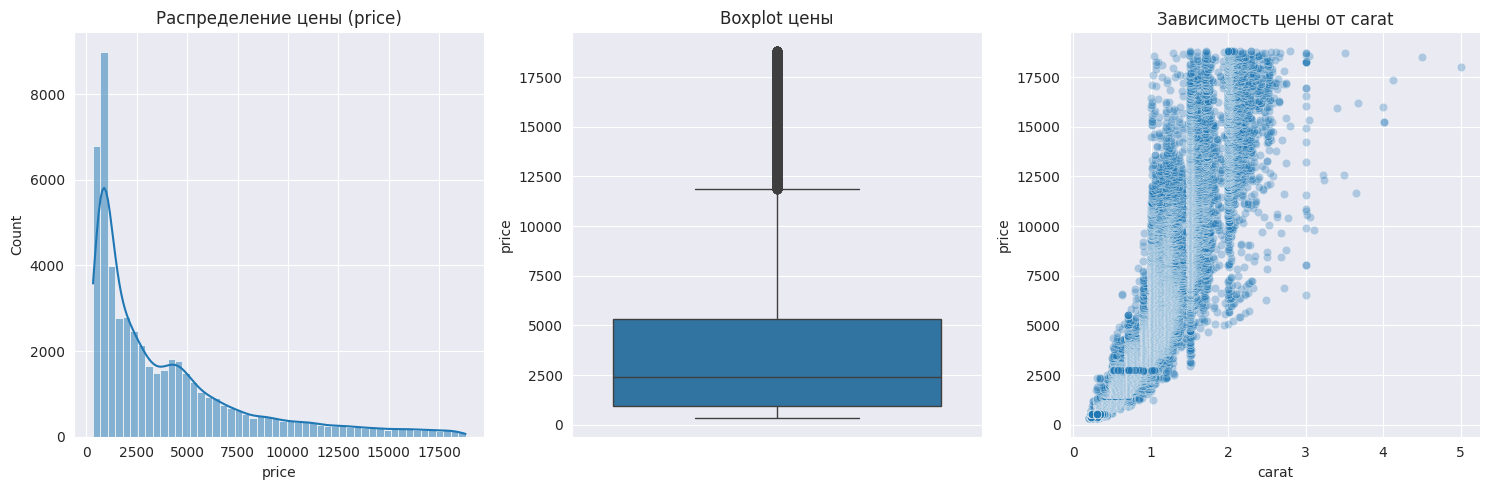

Числовые признаки: ['carat', 'depth', 'table', 'x', 'y', 'z']
Категориальные признаки: ['cut', 'color', 'clarity']

Размер обучающей выборки: (43152, 9)
Размер тестовой выборки: (10788, 9)

Обучение и оценка моделей...

--- Dummy (mean) ---
  R²: -0.1400, RMSE: $4256.95, MAE: $2790.50, MAPE: 111.58%
  CV R² mean: -0.0002 (+/- 0.0002)

--- Linear Regression ---
  R²: 0.9062, RMSE: $1221.37, MAE: $536.18, MAPE: 12.38%
  CV R² mean: 0.9647 (+/- 0.0057)

--- Lasso ---
  R²: -0.1400, RMSE: $4256.95, MAE: $2790.50, MAPE: 111.58%
  CV R² mean: -0.0002 (+/- 0.0002)

--- Ridge ---
  R²: 0.9059, RMSE: $1222.79, MAE: $536.43, MAPE: 12.38%
  CV R² mean: 0.9647 (+/- 0.0058)

--- Elastic Net ---
  R²: 0.3588, RMSE: $3192.60, MAE: $1919.11, MAPE: 61.47%
  CV R² mean: 0.6014 (+/- 0.0019)

--- Bayesian Ridge ---
  R²: 0.9061, RMSE: $1221.62, MAE: $536.22, MAPE: 12.38%
  CV R² mean: 0.9647 (+/- 0.0058)

--- Huber ---
  R²: 0.9434, RMSE: $948.70, MAE: $469.50, MAPE: 11.60%
  CV R² mean: 0.9492 (+/- 0.031

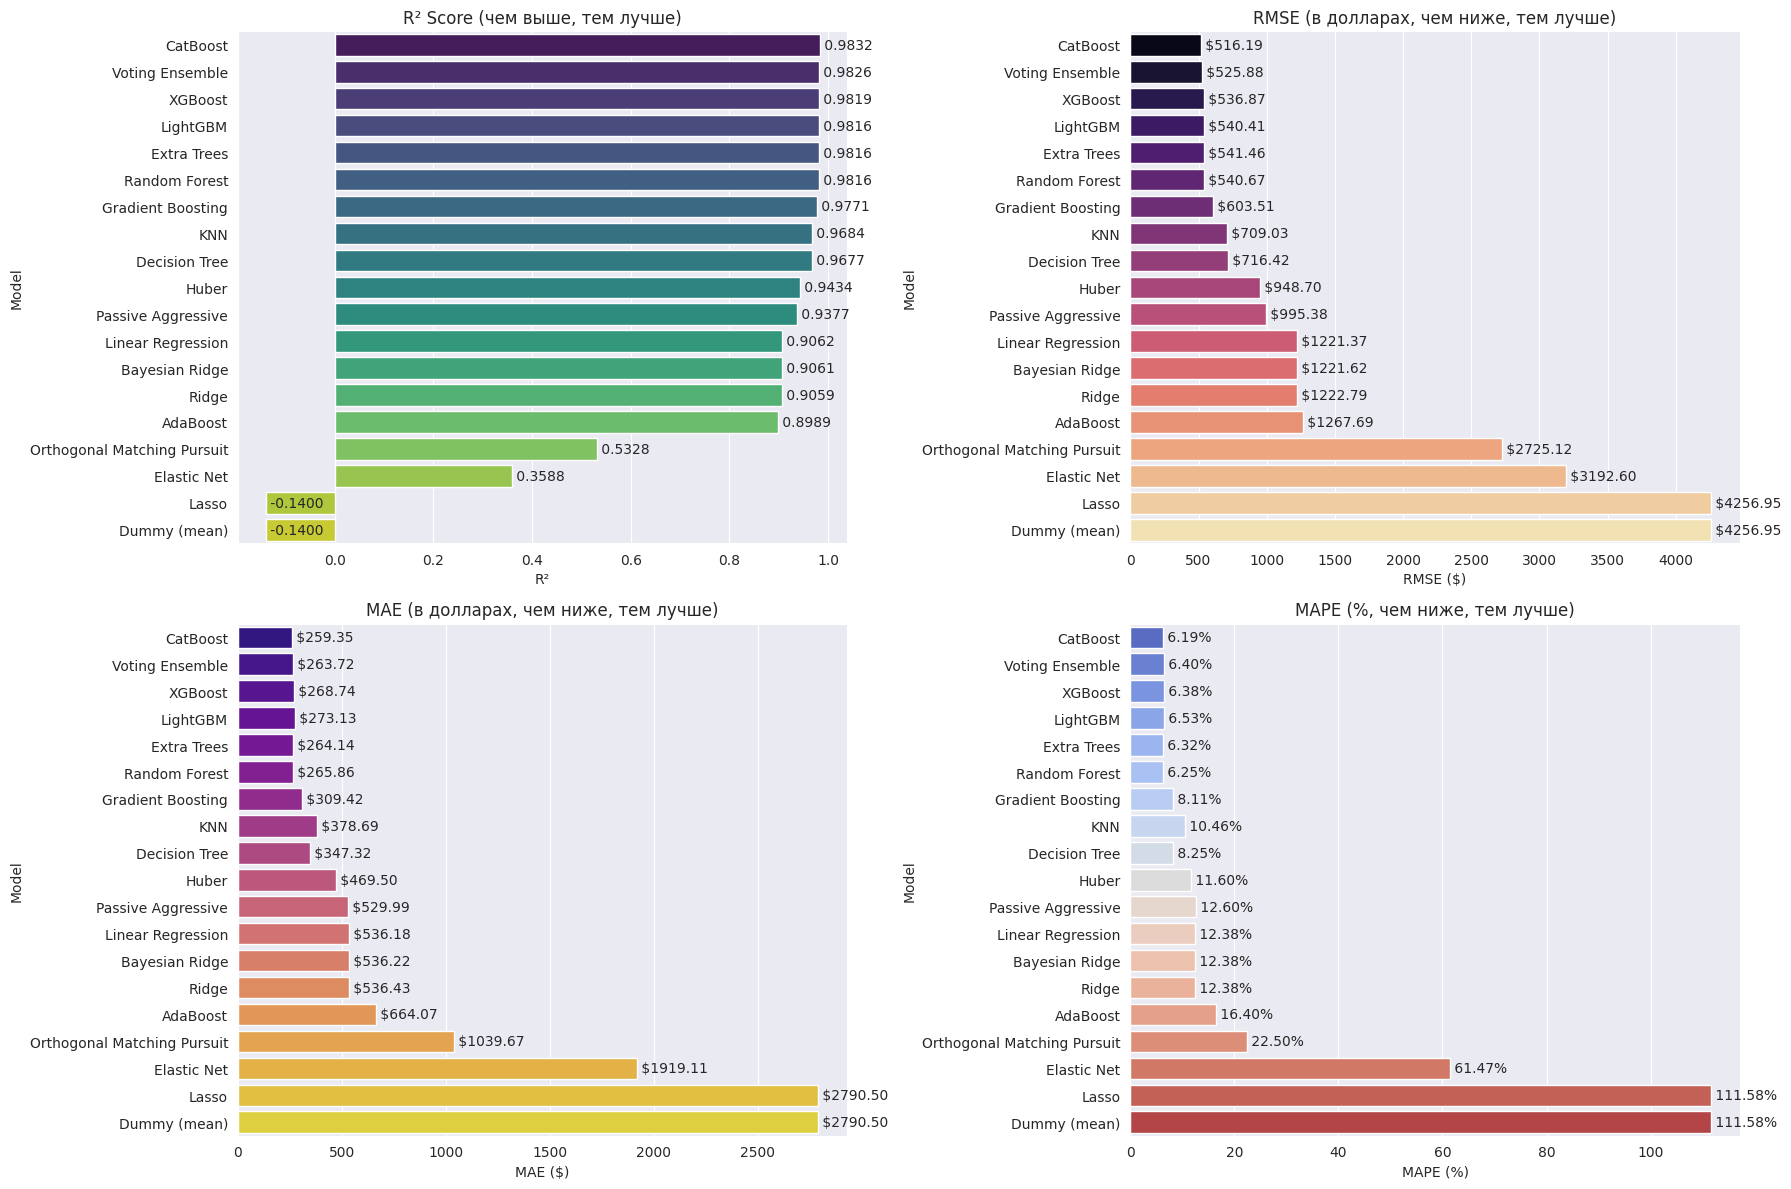


ТОП-5 ЛУЧШИХ МОДЕЛЕЙ ПО МЕТРИКЕ R²
          Model     R2   RMSE    MAE  MAPE
       CatBoost 0.9832 516.19 259.35  6.19
Voting Ensemble 0.9826 525.88 263.72  6.40
        XGBoost 0.9819 536.87 268.74  6.38
       LightGBM 0.9816 540.41 273.13  6.53
    Extra Trees 0.9816 541.46 264.14  6.32

ТОП-5 ЛУЧШИХ МОДЕЛЕЙ ПО МЕТРИКЕ MAPE (наименьшая ошибка)
          Model  MAPE     R2   RMSE    MAE
       CatBoost  6.19 0.9832 516.19 259.35
  Random Forest  6.25 0.9816 540.67 265.86
    Extra Trees  6.32 0.9816 541.46 264.14
        XGBoost  6.38 0.9819 536.87 268.74
Voting Ensemble  6.40 0.9826 525.88 263.72

 Лучшая модель по R²: CatBoost (R² = 0.9832, MAPE = 6.19%)


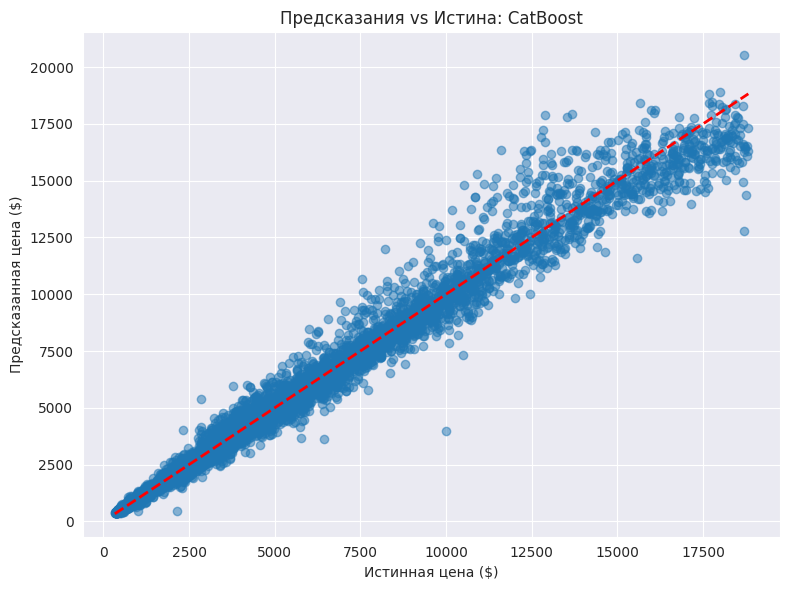


Таблица сравнения сохранена в 'model_comparison.csv'
Предсказания лучшей модели сохранены в 'best_model_predictions.csv'

 Анализ завершён.


In [3]:
# подготовка среды и загрузка данных

!pip install kagglehub pandas numpy matplotlib seaborn scikit-learn catboost lightgbm xgboost -q

import kagglehub
import pandas as pd
import numpy as np
import os
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_absolute_percentage_error

# импорт регрессоров
from sklearn.linear_model import LinearRegression, Lasso, Ridge, BayesianRidge, HuberRegressor, ElasticNet, PassiveAggressiveRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor, ExtraTreesRegressor, AdaBoostRegressor, VotingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import OrthogonalMatchingPursuit
from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor

# настройка отображения
pd.set_option('display.max_columns', None)
sns.set_style('darkgrid')

# аутентификация Kaggle
print("Аутентификация Kaggle...")
kagglehub.login()

# скачивание датасета
print("Скачивание датасета...")
path = kagglehub.dataset_download("swatikhedekar/price-prediction-of-diamond")
print("Датасет скачан в:", path)

# поиск файла
files = os.listdir(path)
print("Содержимое папки:", files)
csv_file = [f for f in files if f.endswith('.csv')][0]
file_path = os.path.join(path, csv_file)

# загрузка данных
df = pd.read_csv(file_path)
print(f"\nРазмер датасета: {df.shape}")
print("Первые 5 строк:")
df.head()

# первичный анализ и предобработка

print("\nИнформация о данных:")
df.info()

print("\nСтатистика:")
df.describe()

print("\nПропуски:")
print(df.isnull().sum())

# анализ целевой переменной (price)
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
sns.histplot(df['price'], bins=50, kde=True)
plt.title('Распределение цены (price)')
plt.subplot(1, 3, 2)
sns.boxplot(y=df['price'])
plt.title('Boxplot цены')
plt.subplot(1, 3, 3)
sns.scatterplot(x=df['carat'], y=df['price'], alpha=0.3)
plt.title('Зависимость цены от carat')
plt.tight_layout()
plt.show()

# распределение цены сильно скошено вправо, есть выбросы.
# используем логарифмирование целевой переменной.
df['log_price'] = np.log1p(df['price'])

# определение признаков
categorical_cols = ['cut', 'color', 'clarity']
numeric_cols = ['carat', 'depth', 'table', 'x', 'y', 'z']

# проверяем, что все колонки есть
categorical_cols = [col for col in categorical_cols if col in df.columns]
numeric_cols = [col for col in numeric_cols if col in df.columns]

print(f"Числовые признаки: {numeric_cols}")
print(f"Категориальные признаки: {categorical_cols}")

# порядок для категориальных признаков
cut_order = ['Fair', 'Good', 'Very Good', 'Premium', 'Ideal']
color_order = ['D', 'E', 'F', 'G', 'H', 'I', 'J']
clarity_order = ['IF', 'VVS1', 'VVS2', 'VS1', 'VS2', 'SI1', 'SI2', 'I1']

# создаём трансформеры
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),
        ('cat', OrdinalEncoder(categories=[cut_order, color_order, clarity_order]), categorical_cols)
    ])

# разделение данных

y = df['log_price']
X = df[numeric_cols + categorical_cols]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"\nРазмер обучающей выборки: {X_train.shape}")
print(f"Размер тестовой выборки: {X_test.shape}")

# определение моделей

models = {
    'Dummy (mean)': DummyRegressor(strategy='mean'),
    'Linear Regression': LinearRegression(),
    'Lasso': Lasso(random_state=42, max_iter=2000),
    'Ridge': Ridge(random_state=42),
    'Elastic Net': ElasticNet(random_state=42, max_iter=2000),
    'Bayesian Ridge': BayesianRidge(),
    'Huber': HuberRegressor(max_iter=1000),
    'Passive Aggressive': PassiveAggressiveRegressor(random_state=42, max_iter=1000),
    'Orthogonal Matching Pursuit': OrthogonalMatchingPursuit(),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'KNN': KNeighborsRegressor(),
    'Random Forest': RandomForestRegressor(random_state=42, n_jobs=-1),
    'Extra Trees': ExtraTreesRegressor(random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42),
    'AdaBoost': AdaBoostRegressor(random_state=42),
    'XGBoost': XGBRegressor(random_state=42, eval_metric='rmse'),
    'LightGBM': LGBMRegressor(random_state=42, verbose=-1, n_jobs=-1),
    'CatBoost': CatBoostRegressor(random_state=42, verbose=0),
    'Voting Ensemble': VotingRegressor([
        ('gbr', GradientBoostingRegressor(random_state=42)),
        ('rfr', RandomForestRegressor(random_state=42, n_jobs=-1)),
        ('xgb', XGBRegressor(random_state=42, eval_metric='rmse'))
    ])
}

# функция для оценки одной модели

def evaluate_model(model, model_name, X_train, y_train, X_test, y_test, X, y, preprocessor):
    pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                               ('regressor', model)])
    pipeline.fit(X_train, y_train)
    y_pred_log = pipeline.predict(X_test)
    y_test_orig = np.expm1(y_test)
    y_pred_orig = np.expm1(y_pred_log)

    r2 = r2_score(y_test_orig, y_pred_orig)
    rmse = np.sqrt(mean_squared_error(y_test_orig, y_pred_orig))
    mae = mean_absolute_error(y_test_orig, y_pred_orig)
    mape = mean_absolute_percentage_error(y_test_orig, y_pred_orig) * 100

    cv = KFold(n_splits=5, shuffle=True, random_state=42)
    cv_scores = cross_val_score(pipeline, X, y, cv=cv, scoring='r2', n_jobs=-1)

    print(f"\n--- {model_name} ---")
    print(f"  R²: {r2:.4f}, RMSE: ${rmse:.2f}, MAE: ${mae:.2f}, MAPE: {mape:.2f}%")
    print(f"  CV R² mean: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

    return {
        'Model': model_name,
        'R2': round(r2, 4),
        'RMSE': round(rmse, 2),
        'MAE': round(mae, 2),
        'MAPE': round(mape, 2),
        'CV R2 Mean': round(cv_scores.mean(), 4)
    }

# обучение и сбор результатов

print("\n" + "="*80)
print("Обучение и оценка моделей...")
print("="*80)

results_list = []

# перебираем все модели из словаря (вместо длинного ручного перечисления)
for name, model in models.items():
    result = evaluate_model(model, name, X_train, y_train, X_test, y_test, X, y, preprocessor)
    results_list.append(result)

# создаём DataFrame и сортируем по R²
results_df = pd.DataFrame(results_list)
results_df = results_df.sort_values(by='R2', ascending=False).reset_index(drop=True)

print("\n" + "="*80)
print("ИТОГОВАЯ ТАБЛИЦА СРАВНЕНИЯ")
print("="*80)
print(results_df.to_string(index=False))

# визуализация сравнения моделей

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# R²
sns.barplot(data=results_df, x='R2', y='Model', palette='viridis', ax=axes[0,0])
axes[0,0].set_title('R² Score (чем выше, тем лучше)')
axes[0,0].set_xlabel('R²')
for i, v in enumerate(results_df['R2']):
    axes[0,0].text(v, i, f' {v:.4f}', va='center')

# RMSE
sns.barplot(data=results_df, x='RMSE', y='Model', palette='magma', ax=axes[0,1])
axes[0,1].set_title('RMSE (в долларах, чем ниже, тем лучше)')
axes[0,1].set_xlabel('RMSE ($)')
for i, v in enumerate(results_df['RMSE']):
    axes[0,1].text(v, i, f' ${v:.2f}', va='center')

# MAE
sns.barplot(data=results_df, x='MAE', y='Model', palette='plasma', ax=axes[1,0])
axes[1,0].set_title('MAE (в долларах, чем ниже, тем лучше)')
axes[1,0].set_xlabel('MAE ($)')
for i, v in enumerate(results_df['MAE']):
    axes[1,0].text(v, i, f' ${v:.2f}', va='center')

# MAPE
sns.barplot(data=results_df, x='MAPE', y='Model', palette='coolwarm', ax=axes[1,1])
axes[1,1].set_title('MAPE (%, чем ниже, тем лучше)')
axes[1,1].set_xlabel('MAPE (%)')
for i, v in enumerate(results_df['MAPE']):
    axes[1,1].text(v, i, f' {v:.2f}%', va='center')

plt.tight_layout()
plt.show()

# анализ лучших моделей

print("\n" + "="*80)
print("ТОП-5 ЛУЧШИХ МОДЕЛЕЙ ПО МЕТРИКЕ R²")
print("="*80)
top5 = results_df.head(5)
print(top5[['Model', 'R2', 'RMSE', 'MAE', 'MAPE']].to_string(index=False))

print("\n" + "="*80)
print("ТОП-5 ЛУЧШИХ МОДЕЛЕЙ ПО МЕТРИКЕ MAPE (наименьшая ошибка)")
print("="*80)
top5_mape = results_df.sort_values(by='MAPE', ascending=True).head(5)
print(top5_mape[['Model', 'MAPE', 'R2', 'RMSE', 'MAE']].to_string(index=False))

# выбор абсолютного лидера (по R²)
best_model_name = results_df.iloc[0]['Model']
best_r2 = results_df.iloc[0]['R2']
best_mape = results_df.iloc[0]['MAPE']

print(f"\n Лучшая модель по R²: {best_model_name} (R² = {best_r2:.4f}, MAPE = {best_mape:.2f}%)")

# предсказания лучшей модели и визуализация

best_model = models[best_model_name]
best_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                                ('regressor', best_model)])
best_pipeline.fit(X_train, y_train)
y_pred_log = best_pipeline.predict(X_test)
y_test_orig = np.expm1(y_test)
y_pred_orig = np.expm1(y_pred_log)

plt.figure(figsize=(8, 6))
plt.scatter(y_test_orig, y_pred_orig, alpha=0.5)
plt.plot([y_test_orig.min(), y_test_orig.max()],
         [y_test_orig.min(), y_test_orig.max()], 'r--', lw=2)
plt.xlabel('Истинная цена ($)')
plt.ylabel('Предсказанная цена ($)')
plt.title(f'Предсказания vs Истина: {best_model_name}')
plt.tight_layout()
plt.show()

# сохранение результатов (метрики и предсказания)

# сохраняем таблицу с метриками в CSV
results_df.to_csv('model_comparison.csv', index=False)
print("\nТаблица сравнения сохранена в 'model_comparison.csv'")

# сохраняем предсказания лучшей модели на тестовой выборке (пример submission)
submission = pd.DataFrame({
    'Id': np.arange(len(y_test_orig)),
    'True_Price': y_test_orig,
    'Predicted_Price': y_pred_orig
})
submission.to_csv('best_model_predictions.csv', index=False)
print("Предсказания лучшей модели сохранены в 'best_model_predictions.csv'")

print("\n Анализ завершён.")